<a href="https://colab.research.google.com/github/mireillejb/FallDetectionSys/blob/main/article4_config_B_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📗 Config B — Anticipation-Enhanced Detection

## Research Question
**Does pre-training the encoder on anticipation (predicting pre-fall states)
improve fall detection compared to a randomly initialized encoder?**

## Key Design Principle
Config B is **architecturally identical** to Config A for detection.
The **only** difference is encoder initialization:

```
Config A : Encoder(random init)      → z(512) → DetHead → FALL/NON-FALL
Config B : Encoder(ant-pre-trained)  → z(512) → DetHead → FALL/NON-FALL
            └── pre-trained on: STABLE / PRE-FALL / FALL (3-class)
```

## Training Protocol
```
Phase 0 : CNN+LSTM on CASIA-B → learns normal gait dynamics
Phase 1 : Transfer LSTM → BiLSTM | Train (Encoder + AntHead)
          → Encoder learns to distinguish STABLE / PRE-FALL / FALL
Phase 2 : Freeze AntHead | Train (Encoder + DetHead) — identical to Config A Phase 2
          → DetHead exploits fall-aware encoder representations
Phase 3 : Unfreeze all | Joint fine-tuning (λ=0.02→0.01)
```

## ⚠️ Prerequisites
Run **Notebook A first** — this notebook loads:
- `/content/casia_best.pth` — CASIA CNN+LSTM weights
- `/content/split_info.pkl` — identical train/val/test split
- `/content/results_A.pkl` — Config A results for comparison

In [1]:
# =============================================================
# CELL 1 — Imports, Seeds, Device
# Identical to Config A for reproducibility
# =============================================================
import os, pickle, cv2, math, random, gc, subprocess, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# ── Reproducibility ──────────────────────────────────────────
SEED = 42  # Must match Config A
random.seed(SEED);  np.random.seed(SEED)
torch.manual_seed(SEED);  torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Environment ready')
print(f'   PyTorch  : {torch.__version__}')
print(f'   Device   : {DEVICE}')
print(f'   SEED     : {SEED} (must match Config A)')

✅ Environment ready
   PyTorch  : 2.11.0+cu128
   Device   : cuda
   SEED     : 42 (must match Config A)


In [2]:
# =============================================================
# CELL 2 — Hyperparameters & Feature Extraction
# =============================================================

# ── Dataset parameters ───────────────────────────────────────
WINDOW_SIZE     = 30   # frames per window
PREDICT_STEPS   = 8    # CASIA: predict next N frames
STRIDE_CASIA    = 5    # CASIA window stride
STRIDE_FALL     = 1    # Le2i FALL stride=1 → maximize FALL windows
STRIDE_ADL      = 5    # Le2i ADL stride=5
FPS_EXTRACT     = 10   # MediaPipe extraction fps
FPS_ORIG        = 25   # Le2i original fps
FPS_LE2I        = 25   # for lead time computation
N_JOINTS        = 17   # COCO keypoints
INPUT_DIM       = 34   # 17 joints × 2 coords
PRE_FALL_FRAMES = 20   # frames before fall_start labeled as PRE-FALL

# ── Training parameters Config B ─────────────────────────────
EP_CASIA = 80    # CASIA CNN+LSTM pre-training epochs
EP_P1    = 120   # Phase 1: anticipation pre-training
EP_P2    = 200   # Phase 2: detection fine-tuning (encoder frozen)
EP_P3    = 50    # Phase 3: joint fine-tuning
LR_P1    = 1e-3  # Phase 1 learning rate
LR_P2    = 1e-3  # Phase 2 learning rate
LR_P3    = 5e-5  # Phase 3 learning rate (very small)
LAM_START= 0.02  # Phase 3 lambda start
LAM_END  = 0.01  # Phase 3 lambda end


def extract_features(kp_seq: np.ndarray) -> np.ndarray:
    """
    Hip-centered, torso-normalized skeleton features.
    Input  : (T, 17, 2) keypoint sequence
    Output : (T, 34) normalized feature vector
    """
    xy         = kp_seq[:, :, :2].copy().astype(np.float32)
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    rel        = xy - hip_center[:, np.newaxis, :]
    torso_h    = np.linalg.norm(xy[:, 0, :] - hip_center, axis=1, keepdims=True)
    torso_h    = np.where(torso_h < 1e-6, 1.0, torso_h)
    return (rel / torso_h[:, np.newaxis, :]).reshape(len(kp_seq), -1).astype(np.float32)


print('✅ Hyperparameters set')
print(f'   Window={WINDOW_SIZE} | Stride FALL={STRIDE_FALL} | PRE_FALL={PRE_FALL_FRAMES}')
print(f'   Phases : P1={EP_P1}ep | P2={EP_P2}ep | P3={EP_P3}ep')

✅ Hyperparameters set
   Window=30 | Stride FALL=1 | PRE_FALL=20
   Phases : P1=120ep | P2=200ep | P3=50ep


In [3]:
# =============================================================
# CELL 3 — Download Datasets
# =============================================================
!pip install kagglehub mediapipe --quiet
!apt-get install -y ffmpeg > /dev/null 2>&1

import kagglehub
path_casia = kagglehub.dataset_download('mireillejabbour/casia-b-simcc')
path_le2i  = kagglehub.dataset_download('tuyenldvn/falldataset-imvia')
print(f'✅ CASIA-B : {path_casia}')
print(f'✅ Le2i    : {path_le2i}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 15.3 MB/s eta 0:00:00


100%|██████████| 230M/230M [00:01<00:00, 148MB/s]

Extracting files...


100%|██████████| 9.37G/9.37G [01:29<00:00, 112MB/s]

Extracting files...


✅ CASIA-B : /root/.cache/kagglehub/datasets/mireillejabbour/casia-b-simcc/versions/1
✅ Le2i    : /root/.cache/kagglehub/datasets/tuyenldvn/falldataset-imvia/versions/2


In [4]:
# =============================================================
# CELL 4 — CASIA-B CNN+LSTM Pre-training
#
# Architecture:
#   CNN  : linear layers applied per-frame (34 → 128 → 64)
#          extracts spatial features from skeleton joints
#   LSTM : 2-layer, hidden=256
#          models temporal gait dynamics
#   Task : predict next 8 frames → learns normal gait patterns
#
# Transfer: LSTM hidden weights → BiLSTM forward direction
# =============================================================

def load_casia_b(root_path: str, conditions: list = ['nm']) -> list:
    """Load CASIA-B skeleton sequences for given walking conditions."""
    root = Path(root_path) / 'CASIA-B_SimCC'
    sequences, skipped = [], 0
    for fp in tqdm(sorted(root.rglob('*.pkl')), desc='Loading CASIA-B'):
        parts = fp.relative_to(root).parts
        if len(parts) < 4: skipped += 1; continue
        cond = parts[1].split('-')[0]
        if conditions and cond not in conditions: continue
        try:
            with open(fp, 'rb') as f: data = pickle.load(f)
            if not isinstance(data, np.ndarray): data = np.array(data, dtype=np.float32)
            if data.ndim != 3 or data.shape[1] != 17 or len(data) < 25: skipped += 1; continue
            sequences.append(data.astype(np.float32))
        except: skipped += 1
    print(f'✅ CASIA-B loaded: {len(sequences)} sequences | {skipped} skipped')
    return sequences


def build_casia_windows(sequences: list):
    """Build (input, target) windows for gait prediction task."""
    X_list, Y_list = [], []
    for seq in tqdm(sequences, desc='Building CASIA windows'):
        feats = extract_features(seq); T = len(feats)
        if T < WINDOW_SIZE + PREDICT_STEPS: continue
        for s in range(0, T - WINDOW_SIZE - PREDICT_STEPS + 1, STRIDE_CASIA):
            e = s + WINDOW_SIZE
            X_list.append(feats[s:e]); Y_list.append(feats[e:e + PREDICT_STEPS])
    X = np.array(X_list, dtype=np.float32); Y = np.array(Y_list, dtype=np.float32)
    print(f'✅ CASIA windows: X={X.shape} | Y={Y.shape}')
    return X, Y


class CASIAAnticipator(nn.Module):
    """
    CNN + LSTM model for normal gait pre-training on CASIA-B.

    Architecture:
        CNN per frame : Linear(34→128) → ReLU → Linear(128→64) → ReLU
        LSTM          : 2-layer, hidden=256, predicts next 8 frames

    After training, LSTM weights are transferred to the BiLSTM encoder
    used for fall detection (forward direction only).
    """
    def __init__(self, input_size=34, cnn_out=64, hidden_size=256,
                 num_layers=2, predict_steps=PREDICT_STEPS, dropout=0.3):
        super().__init__()
        self.predict_steps = predict_steps
        self.cnn = nn.Sequential(
            nn.Linear(input_size, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, cnn_out),    nn.ReLU()
        )
        self.lstm = nn.LSTM(
            input_size=cnn_out, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, input_size * predict_steps)
        )
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias' in name: nn.init.zeros_(p)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape
        h = self.cnn(x.reshape(B * T, D)).reshape(B, T, -1)
        h, _ = self.lstm(h)
        return self.fc(self.dropout(h[:, -1, :])).view(B, self.predict_steps, -1)


# ── Load or train CASIA model ────────────────────────────────
sequences_casia  = load_casia_b(path_casia, conditions=['nm'])
X_casia, Y_casia = build_casia_windows(sequences_casia)

torch.manual_seed(SEED)
model_casia = CASIAAnticipator().to(DEVICE)
n_params    = sum(p.numel() for p in model_casia.parameters())
print(f'✅ CASIAAnticipator: {n_params:,} parameters')

CASIA_CKPT = '/content/casia_best.pth'
if os.path.exists(CASIA_CKPT):
    # ── Reuse weights from Notebook A ────────────────────────
    model_casia.load_state_dict(
        torch.load(CASIA_CKPT, map_location=DEVICE, weights_only=False))
    print(f'✅ CASIA weights loaded from Notebook A ({CASIA_CKPT})')
    print(f'   → Skipping 80 epochs of CASIA training')
else:
    # ── Train from scratch (standalone mode) ─────────────────
    print(f'⚠️  {CASIA_CKPT} not found → training CASIA CNN+LSTM from scratch')

    class GaitDS(Dataset):
        def __init__(self, X, Y):
            self.X = torch.from_numpy(X); self.Y = torch.from_numpy(Y)
        def __len__(self): return len(self.X)
        def __getitem__(self, i): return self.X[i], self.Y[i]

    n_val_c = int(0.2 * len(X_casia))
    ds_c    = GaitDS(X_casia, Y_casia)
    tr_c    = Subset(ds_c, list(range(len(X_casia) - n_val_c)))
    va_c    = Subset(ds_c, list(range(len(X_casia) - n_val_c, len(X_casia))))
    tr_c_ld = DataLoader(tr_c, batch_size=256, shuffle=True,  num_workers=2)
    va_c_ld = DataLoader(va_c, batch_size=256, shuffle=False, num_workers=2)

    criterion_mse = nn.MSELoss()
    optimizer_c   = torch.optim.Adam(model_casia.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler_c   = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_c, mode='min', patience=5, factor=0.5)
    best_mse      = float('inf')

    print(f'   Training {EP_CASIA} epochs...')
    for epoch in range(1, EP_CASIA + 1):
        model_casia.train(); train_loss = 0.0
        for xb, yb in tr_c_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer_c.zero_grad()
            loss = criterion_mse(model_casia(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model_casia.parameters(), 1.0)
            optimizer_c.step()
            train_loss += loss.item()

        model_casia.eval(); val_loss = 0.0
        with torch.no_grad():
            for xb, yb in va_c_ld:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion_mse(model_casia(xb), yb).item()

        train_loss /= len(tr_c_ld); val_loss /= len(va_c_ld)
        scheduler_c.step(val_loss)
        if val_loss < best_mse:
            best_mse = val_loss
            torch.save(model_casia.state_dict(), CASIA_CKPT)
        if epoch % 10 == 0 or epoch == 1:
            print(f'   Ep {epoch:03d} | Train MSE={train_loss:.5f} | Val MSE={val_loss:.5f}')

    model_casia.load_state_dict(
        torch.load(CASIA_CKPT, map_location=DEVICE, weights_only=False))
    print(f'✅ CASIA training done | Best Val MSE = {best_mse:.6f}')

Loading CASIA-B: 100%|██████████| 13640/13640 [00:06<00:00, 2227.35it/s]


✅ CASIA-B loaded: 8175 sequences | 9 skipped


Building CASIA windows: 100%|██████████| 8175/8175 [00:01<00:00, 4949.82it/s]


✅ CASIA windows: X=(107489, 30, 34) | Y=(107489, 8, 34)
✅ CASIAAnticipator: 1,004,496 parameters
⚠️  /content/casia_best.pth not found → training CASIA CNN+LSTM from scratch
   Training 80 epochs...
   Ep 001 | Train MSE=0.05316 | Val MSE=0.05559
   Ep 010 | Train MSE=0.02948 | Val MSE=0.04192
   Ep 020 | Train MSE=0.02920 | Val MSE=0.04182
   Ep 030 | Train MSE=0.02917 | Val MSE=0.04173
   Ep 040 | Train MSE=0.02910 | Val MSE=0.04167
   Ep 050 | Train MSE=0.02905 | Val MSE=0.04169
   Ep 060 | Train MSE=0.02905 | Val MSE=0.04166
   Ep 070 | Train MSE=0.02904 | Val MSE=0.04166
   Ep 080 | Train MSE=0.02904 | Val MSE=0.04167
✅ CASIA training done | Best Val MSE = 0.041640


In [5]:
# =============================================================
# CELL 5 — Model Architecture
#
# Shared encoder: Multi-Scale CNN-BiLSTM
#   - 3 CNN branches (kernel 3, 7, 15) → capture multi-scale temporal patterns
#   - BiLSTM (2-layer, hidden=256, bidirectional) → temporal dynamics
#   - Temporal attention → context vector z (512-dim)
#
# Config B model:
#   - ant_head: 3-class classifier (STABLE / PRE-FALL / FALL)
#     Used ONLY during Phase 1. Discarded after pre-training.
#   - det_head: IDENTICAL to Config A
#     Receives z from the anticipation-aware encoder.
# =============================================================

class MultiScaleCNNBiLSTM(nn.Module):
    """
    Multi-scale temporal encoder for skeleton sequences.

    Three parallel CNN branches capture complementary temporal scales:
        kernel=3  → local patterns (impact dynamics)
        kernel=7  → medium patterns (fall onset)
        kernel=15 → global patterns (pre-fall degradation)

    Fused features are processed by a bidirectional LSTM and
    aggregated via learnable temporal attention into z ∈ R^512.
    """
    def __init__(self, input_dim: int = 34, lstm_h: int = 256, dropout: float = 0.3):
        super().__init__()
        ch = 64
        self.cnn3   = nn.Sequential(nn.Conv1d(input_dim, ch, 3,  padding=1),  nn.BatchNorm1d(ch), nn.ReLU())
        self.cnn7   = nn.Sequential(nn.Conv1d(input_dim, ch, 7,  padding=3),  nn.BatchNorm1d(ch), nn.ReLU())
        self.cnn15  = nn.Sequential(nn.Conv1d(input_dim, ch, 15, padding=7),  nn.BatchNorm1d(ch), nn.ReLU())
        self.fusion = nn.Sequential(nn.Conv1d(ch * 3, 128, 1), nn.BatchNorm1d(128), nn.ReLU())
        self.bilstm = nn.LSTM(128, lstm_h, num_layers=2, batch_first=True,
                               bidirectional=True, dropout=dropout)
        self.attn   = nn.Sequential(nn.Linear(lstm_h * 2, lstm_h), nn.Tanh(),
                                     nn.Linear(lstm_h, 1))
        self.dropout = nn.Dropout(dropout)
        self.out_dim = lstm_h * 2  # 512

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        xT = x.permute(0, 2, 1)  # (B, 34, T)
        h  = self.fusion(torch.cat([self.cnn3(xT), self.cnn7(xT), self.cnn15(xT)], dim=1))
        h, _ = self.bilstm(h.permute(0, 2, 1))  # (B, T, 512)
        h  = self.dropout(h)
        w  = torch.softmax(self.attn(h), dim=1)  # (B, T, 1)
        return (w * h).sum(dim=1)  # (B, 512)


class AnticipateThenDetectModel(nn.Module):
    """
    Config B — Anticipation-Enhanced Detection Model.

    The anticipation head (ant_head) is used ONLY during Phase 1
    to shape the encoder's representations. It is then frozen and
    the detection head (det_head) is trained on the pre-trained encoder.

    Scientific argument:
        The encoder pre-trained on 3-class anticipation has learned to
        represent STABLE, PRE-FALL, and FALL states distinctly in the
        latent space z. This richer temporal representation is hypothesized
        to improve the detection head's ability to classify FALL vs NON-FALL.

    Comparison with Config A:
        - det_head architecture: IDENTICAL
        - encoder architecture:  IDENTICAL
        - ONLY difference: encoder initialization via anticipation pre-training
    """
    def __init__(self, dropout: float = 0.3):
        super().__init__()
        # Shared encoder — same architecture as Config A
        self.encoder  = MultiScaleCNNBiLSTM(dropout=dropout)

        # Anticipation head — 3-class: STABLE / PRE-FALL / FALL
        # Used ONLY during Phase 1 pre-training
        self.ant_head = nn.Sequential(
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 3)   # 0=STABLE | 1=PRE-FALL | 2=FALL
        )

        # Detection head — IDENTICAL to Config A
        self.det_head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 2)   # 0=NON-FALL | 1=FALL
        )

    def forward(self, x: torch.Tensor):
        z         = self.encoder(x)              # (B, 512)
        logits_A  = self.ant_head(z)             # (B, 3)  — anticipation
        logits_D  = self.det_head(z)             # (B, 2)  — detection
        p_ant     = torch.softmax(logits_A, dim=1)
        return logits_A, logits_D, p_ant


def transfer_lstm_to_bilstm(casia_model: nn.Module,
                             bilstm_module: nn.Module) -> nn.Module:
    """
    Transfer hidden-to-hidden weights and biases from CASIA LSTM
    to the forward direction of the BiLSTM encoder.

    Transferred tensors (forward direction only):
        weight_hh_l0, weight_hh_l1  : (4*256, 256) — identical shape
        bias_ih_l0, bias_hh_l0      : (4*256,)
        bias_ih_l1, bias_hh_l1      : (4*256,)
    """
    src_state = casia_model.lstm.state_dict()
    dst_state = bilstm_module.state_dict()
    count = 0
    for layer in range(2):
        for wtype in ['weight_hh', 'bias_ih', 'bias_hh']:
            src_key = f'{wtype}_l{layer}'
            dst_key = f'{wtype}_l{layer}'  # forward direction
            if src_key not in src_state or dst_key not in dst_state: continue
            sw = src_state[src_key]; dw = dst_state[dst_key].clone()
            if sw.dim() == 2:
                nr = min(sw.shape[0], dw.shape[0]); nc = min(sw.shape[1], dw.shape[1])
                dw[:nr, :nc] = sw[:nr, :nc]
            else:
                n = min(sw.shape[0], dw.shape[0]); dw[:n] = sw[:n]
            dst_state[dst_key] = dw; count += 1
    bilstm_module.load_state_dict(dst_state)
    print(f'✅ LSTM → BiLSTM transfer: {count} tensors (forward direction)')
    return bilstm_module


# ── Instantiate Config B ──────────────────────────────────────
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
model_B = AnticipateThenDetectModel().to(DEVICE)
model_B.encoder.bilstm = transfer_lstm_to_bilstm(model_casia, model_B.encoder.bilstm)

n_total   = sum(p.numel() for p in model_B.parameters() if p.requires_grad)
n_encoder = sum(p.numel() for p in model_B.encoder.parameters())
n_ant     = sum(p.numel() for p in model_B.ant_head.parameters())
n_det     = sum(p.numel() for p in model_B.det_head.parameters())
print(f'\n✅ Config B instantiated')
print(f'   Total params    : {n_total:,}')
print(f'   Encoder         : {n_encoder:,}')
print(f'   Ant head (P1)   : {n_ant:,}  ← frozen after Phase 1')
print(f'   Det head (A≡B)  : {n_det:,}  ← identical to Config A')

# Shape verification
dummy = torch.randn(4, WINDOW_SIZE, INPUT_DIM).to(DEVICE)
lA, lD, pA = model_B(dummy)
print(f'\n   Forward check: ant={lA.shape} (3-cls) | det={lD.shape} (2-cls)')

✅ LSTM → BiLSTM transfer: 6 tensors (forward direction)

✅ Config B instantiated
   Total params    : 2,809,542
   Encoder         : 2,579,009
   Ant head (P1)   : 66,051  ← frozen after Phase 1
   Det head (A≡B)  : 164,482  ← identical to Config A

   Forward check: ant=torch.Size([4, 3]) (3-cls) | det=torch.Size([4, 2]) (2-cls)


In [6]:
# =============================================================
# CELL 6 — Le2i Dataset | Self-Contained Split (No Drive, No Notebook A dependency)
# =============================================================
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import urllib.request

LE2I_PKL   = '/content/le2i_data.pkl'
SPLIT_PKL  = '/content/split_info.pkl'
MP_TO_COCO = [0,2,5,7,8,11,12,13,14,15,16,23,24,25,26,27,28]

# ── Load Le2i skeleton data ───────────────────────────────────
if os.path.exists(LE2I_PKL):
    with open(LE2I_PKL, 'rb') as f: labeled_data = pickle.load(f)
    for d in labeled_data: d['keypoints'] = d['keypoints'].astype(np.float32)
    fall_n = sum(1 for d in labeled_data if d['is_fall'])
    print(f'✅ Le2i loaded: {len(labeled_data)} sequences | FALL={fall_n} | ADL={len(labeled_data)-fall_n}')
else:
    print('⚠️  Le2i PKL not found → running MediaPipe extraction...')
    MODEL_PATH = '/content/pose_landmarker.task'
    if not os.path.exists(MODEL_PATH):
        urllib.request.urlretrieve(
            'https://storage.googleapis.com/mediapipe-models/pose_landmarker/'
            'pose_landmarker_lite/float16/latest/pose_landmarker_lite.task', MODEL_PATH)
    root = Path(path_le2i)
    def read_ann(tp):
        for enc in ['utf-8','latin-1','cp1252']:
            try:
                with open(tp,'r',encoding=enc) as f: lines=[l.strip() for l in f if l.strip()]
                if not lines: return None,None
                l1=lines[0]; l2=lines[1] if len(lines)>1 else '0'
                if ',' in l1: return 'ADL',None
                try: fs=int(l1)
                except: return None,None
                if fs==0: return 'ADL',None
                try: fe=int(l2)
                except: return 'ADL',None
                return ('FALL',(fs,fe)) if fe>fs else ('ADL',None)
            except: continue
        return None,None
    def find_txt(vp):
        pd_=vp.parent.parent; tn=vp.stem+'.txt'
        for af in ['Annotation_files','Annotations_files']:
            if (pd_/af/tn).exists(): return pd_/af/tn
        for tp in pd_.rglob(tn): return tp
        return None
    all_v=sorted(list(root.rglob('*.avi'))+list(root.rglob('*.AVI')))
    fall_list,adl_list=[],[]
    for v in all_v:
        rl=str(v.relative_to(root)).lower()
        if any(k in rl for k in ['lecture','office']): continue
        tp=find_txt(v)
        if tp is None: continue
        lbl,ann=read_ann(tp)
        if lbl=='FALL': fall_list.append((v,ann[0],ann[1]))
        elif lbl=='ADL': adl_list.append(v)
    fd=[(vp,fs,fe,cv2.VideoCapture(str(vp)).get(cv2.CAP_PROP_FRAME_COUNT)) for vp,fs,fe in fall_list]
    fd.sort(key=lambda x:x[3],reverse=True); fall_list=[(v,fs,fe) for v,fs,fe,_ in fd[:93]]
    opts=mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
        num_poses=1,min_pose_detection_confidence=0.1,
        min_pose_presence_confidence=0.1,min_tracking_confidence=0.1,
        running_mode=mp_vision.RunningMode.IMAGE)
    detector=mp_vision.PoseLandmarker.create_from_options(opts)
    zeros_kp=np.zeros((17,2),dtype=np.float32); result=[]; stats={'fall':0,'adl':0,'skip':0}
    tmp_dir='/content/tmp_frames'
    def extract_kp(frame_bgr):
        try:
            if frame_bgr is None or frame_bgr.size==0: return None
            img=(cv2.cvtColor(frame_bgr,cv2.COLOR_GRAY2RGB) if len(frame_bgr.shape)==2
                 else cv2.cvtColor(frame_bgr,cv2.COLOR_BGR2RGB))
            h,w=img.shape[:2]
            if h<10 or w<10: return None
            res=detector.detect(mp.Image(image_format=mp.ImageFormat.SRGB,data=img))
            if not res.pose_landmarks: return None
            lms=res.pose_landmarks[0]; kp=np.zeros((17,2),dtype=np.float32)
            for ci,mi in enumerate(MP_TO_COCO): kp[ci,0]=lms[mi].x*w; kp[ci,1]=lms[mi].y*h
            return kp
        except: return None
    def proc_vid(vpath):
        if os.path.exists(tmp_dir): shutil.rmtree(tmp_dir)
        os.makedirs(tmp_dir)
        subprocess.run(['ffmpeg','-i',str(vpath),'-vf',f'fps={FPS_EXTRACT}',
            '-q:v','2','-loglevel','error',f'{tmp_dir}/frame_%04d.png'],
            timeout=60,capture_output=True,check=False)
        frames=sorted(Path(tmp_dir).glob('frame_*.png'))
        if len(frames)<WINDOW_SIZE: return None
        kp_l=[]
        for fp in frames:
            fr=cv2.imread(str(fp)); kp=extract_kp(fr)
            kp_l.append(kp if kp is not None else zeros_kp.copy()); del fr
        return np.stack(kp_l).astype(np.float16) if len(kp_l)>=WINDOW_SIZE else None
    def assign_lbl(T,fs_o,fe_o):
        r=FPS_EXTRACT/FPS_ORIG; fs=min(int(round(fs_o*r)),T-1); fe=min(int(round(fe_o*r)),T-1)
        ps=max(0,fs-PRE_FALL_FRAMES)
        ant=np.zeros(T,dtype=np.int64); det=np.zeros(T,dtype=np.int64)
        det[fs:fe+1]=1; ant[ps:fs]=1; ant[fs:]=-1; return ant,det
    for vp,fs,fe in tqdm(fall_list,desc='FALL'):
        try:
            ks=proc_vid(vp)
            if ks is None: stats['skip']+=1; continue
            ant,det=assign_lbl(len(ks),fs,fe)
            result.append({'keypoints':ks,'labels_ant':ant,'labels_det':det,
                           'seq_name':vp.stem,'is_fall':True,'fall_start':fs,'fall_end':fe})
            stats['fall']+=1
        except: stats['skip']+=1
        finally: gc.collect()
    for vp in tqdm(adl_list,desc='ADL'):
        try:
            ks=proc_vid(vp)
            if ks is None: stats['skip']+=1; continue
            T=len(ks)
            result.append({'keypoints':ks,'labels_ant':np.zeros(T,dtype=np.int64),
                           'labels_det':np.zeros(T,dtype=np.int64),
                           'seq_name':vp.stem,'is_fall':False,'fall_start':None,'fall_end':None})
            stats['adl']+=1
        except: stats['skip']+=1
        finally: gc.collect()
    detector.close()
    if os.path.exists(tmp_dir): shutil.rmtree(tmp_dir)
    with open(LE2I_PKL,'wb') as f: pickle.dump(result,f)
    labeled_data=result
    for d in labeled_data: d['keypoints']=d['keypoints'].astype(np.float32)
    print(f'✅ Extracted: FALL={stats["fall"]} | ADL={stats["adl"]} | Skip={stats["skip"]}')

# ── Load split, or regenerate with the EXACT SAME algorithm as Config A ──────
# CRITICAL: this must stay byte-identical to Config A's split logic (Cell 8),
# otherwise A and B are evaluated on different data and the comparison is invalid.
if os.path.exists(SPLIT_PKL):
    with open(SPLIT_PKL, 'rb') as f: split_info = pickle.load(f)
    print(f'✅ Split loaded from existing {SPLIT_PKL} (SEED={split_info["seed"]}) — identical to Config A')
else:
    print(f'⚠️  {SPLIT_PKL} not found → regenerating split with the IDENTICAL procedure used in Config A')
    print('   (per-video, 70/15/15, random.shuffle, SEED-fixed — NOT a different algorithm)')

    # Reseed locally right before the split, exactly as Config A does.
    # As long as nothing else touched the `random` module before this point
    # (true in both notebooks — verified: only random.seed()/np.random.seed() run earlier),
    # this reproduces Config A's split exactly, even without split_info.pkl.
    random.seed(SEED); np.random.seed(SEED)

    fall_seqs = [d for d in labeled_data if d['is_fall']]
    adl_seqs  = [d for d in labeled_data if not d['is_fall']]
    random.shuffle(fall_seqs); random.shuffle(adl_seqs)

    def split3(seqs, v=0.15, t=0.15):
        n = len(seqs); nt = max(1, int(round(t * n))); nv = max(1, int(round(v * n)))
        while nt + nv >= n and nv > 1: nv -= 1
        while nt + nv >= n and nt > 1: nt -= 1
        return seqs[nt+nv:], seqs[nt:nt+nv], seqs[:nt]

    fall_tr, fall_va, fall_te = split3(fall_seqs)
    adl_tr,  adl_va,  adl_te  = split3(adl_seqs)
    train_seqs = fall_tr + adl_tr
    val_seqs   = fall_va + adl_va
    test_seqs  = fall_te + adl_te
    random.shuffle(train_seqs); random.shuffle(val_seqs); random.shuffle(test_seqs)

    split_info = {
        'seed': SEED,
        'train_names': [s['seq_name'] for s in train_seqs],
        'val_names':   [s['seq_name'] for s in val_seqs],
        'test_names':  [s['seq_name'] for s in test_seqs],
    }
    with open(SPLIT_PKL, 'wb') as f: pickle.dump(split_info, f)
    print(f'✅ Split generated (70/15/15, per-video, Config-A-identical) and saved to {SPLIT_PKL}')

train_names = set(split_info['train_names'])
val_names   = set(split_info['val_names'])
test_names  = set(split_info['test_names'])

train_seqs = [d for d in labeled_data if d['seq_name'] in train_names]
val_seqs   = [d for d in labeled_data if d['seq_name'] in val_names]
test_seqs  = [d for d in labeled_data if d['seq_name'] in test_names]

print('\n✅ Split summary:')
for name, seqs in [('Train', train_seqs), ('Val', val_seqs), ('Test', test_seqs)]:
    nf = sum(1 for s in seqs if s['is_fall']); na = len(seqs) - nf
    print(f'   {name:5}: {nf} FALL + {na} ADL = {len(seqs)} sequences')


def build_windows_3class(seqs: list):
    """
    Build windows with 3-class anticipation labels:
        0 = STABLE    (det=0, not pre-fall)
        1 = PRE-FALL  (det=0, within PRE_FALL_FRAMES before fall)
        2 = FALL      (det=1)  ← no masking unlike binary approach

    Using stride=1 for FALL sequences maximizes the number
    of FALL windows available for training and evaluation.
    """
    X_l, ya_l, yd_l = [], [], []
    for s in seqs:
        kp = s['keypoints']; la = s['labels_ant']
        ld = s['labels_det']; T  = len(kp)
        if T < WINDOW_SIZE: continue
        feats  = extract_features(kp)
        stride = STRIDE_FALL if s['is_fall'] else STRIDE_ADL
        for st in range(0, T - WINDOW_SIZE + 1, stride):
            en     = st + WINDOW_SIZE
            det_l  = int(ld[en - 1])
            ant_l  = int(la[en - 1])
            if det_l == 1:   ya_label = 2   # FALL
            elif ant_l == 1: ya_label = 1   # PRE-FALL
            else:            ya_label = 0   # STABLE
            X_l.append(feats[st:en]); ya_l.append(ya_label); yd_l.append(det_l)

    if not X_l:
        return (np.zeros((0, WINDOW_SIZE, INPUT_DIM), dtype=np.float32),
                np.zeros(0, dtype=np.int64), np.zeros(0, dtype=np.int64))
    return (np.array(X_l, dtype=np.float32),
            np.array(ya_l, dtype=np.int64),
            np.array(yd_l, dtype=np.int64))


X_tr, ya_tr, yd_tr = build_windows_3class(train_seqs)
X_va, ya_va, yd_va = build_windows_3class(val_seqs)
X_te, ya_te, yd_te = build_windows_3class(test_seqs)

print(f'\n   Windows: Train={len(X_tr):,} | Val={len(X_va):,} | Test={len(X_te):,}')
print(f'   3-class distribution (Train):')
for i, lbl in enumerate(['STABLE','PRE-FALL','FALL']):
    print(f'     {lbl:10}: {(ya_tr==i).sum():,}')

# ── Balanced sampling: 5:1 NON-FALL:FALL ─────────────────────
np.random.seed(SEED)
idx_fall   = np.where(yd_tr == 1)[0]
idx_nonfal = np.where(yd_tr == 0)[0]
n_nf       = min(len(idx_nonfal), 5 * len(idx_fall))
idx_nf_sel = np.random.choice(idx_nonfal, n_nf, replace=False)
idx_bal    = np.random.permutation(np.concatenate([idx_fall, idx_nf_sel]))
X_tr = X_tr[idx_bal]; ya_tr = ya_tr[idx_bal]; yd_tr = yd_tr[idx_bal]
print(f'\n✅ Balanced train: FALL={idx_fall.size:,} | NON-FALL={n_nf:,} (5:1 ratio)')

class FallDataset(Dataset):
    def __init__(self, X, ya, yd):
        self.X  = torch.from_numpy(X)
        self.ya = torch.from_numpy(ya)
        self.yd = torch.from_numpy(yd)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.ya[i], self.yd[i]

tr_ld  = DataLoader(FallDataset(X_tr,ya_tr,yd_tr), batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_ld = DataLoader(FallDataset(X_va,ya_va,yd_va), batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
te_ld  = DataLoader(FallDataset(X_te,ya_te,yd_te), batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

⚠️  Le2i PKL not found → running MediaPipe extraction...


ADL: 100%|██████████| 34/34 [04:45<00:00,  8.38s/it]


✅ Extracted: FALL=93 | ADL=34 | Skip=0
⚠️  /content/split_info.pkl not found → regenerating split with the IDENTICAL procedure used in Config A
   (per-video, 70/15/15, random.shuffle, SEED-fixed — NOT a different algorithm)
✅ Split generated (70/15/15, per-video, Config-A-identical) and saved to /content/split_info.pkl

✅ Split summary:
   Train: 84 FALL + 27 ADL = 111 sequences
   Val  : 25 FALL + 9 ADL = 34 sequences
   Test : 25 FALL + 9 ADL = 34 sequences

   Windows: Train=7,850 | Val=2,135 | Test=2,616
   3-class distribution (Train):
     STABLE    : 5,662
     PRE-FALL  : 1,401
     FALL      : 787

✅ Balanced train: FALL=787 | NON-FALL=3,935 (5:1 ratio)


In [7]:
# =============================================================
# CELL 7 — Loss Functions & Evaluation Metrics
# =============================================================

class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance.
    FL(p) = (1 - p_t)^gamma * CE(p, y)

    gamma=2.0 down-weights easy examples, focuses on hard cases.
    """
    def __init__(self, gamma: float = 2.0, weight: torch.Tensor = None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce  = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        p_t = torch.exp(-ce)
        return ((1 - p_t) ** self.gamma * ce).mean()


def compute_class_weights(y: np.ndarray, n_classes: int) -> torch.Tensor:
    """Inverse-frequency class weights for imbalanced datasets."""
    counts  = np.bincount(y[y >= 0], minlength=n_classes).astype(float)
    weights = 1.0 / np.maximum(counts, 1)
    return torch.tensor(weights / weights.sum() * n_classes, dtype=torch.float32)


# 3-class weights for anticipation, 2-class for detection
w_ant = compute_class_weights(ya_tr, n_classes=3).to(DEVICE)
w_det = compute_class_weights(yd_tr, n_classes=2).to(DEVICE)

criterion_ant = FocalLoss(gamma=2.0, weight=w_ant)
criterion_det = FocalLoss(gamma=2.0, weight=w_det)

print('✅ Loss functions initialized')
print(f'   Anticipation weights (3-cls): STABLE={w_ant[0]:.3f} | PRE-FALL={w_ant[1]:.3f} | FALL={w_ant[2]:.3f}')
print(f'   Detection weights    (2-cls): NON-FALL={w_det[0]:.3f} | FALL={w_det[1]:.3f}')


def evaluate(model: nn.Module, loader: DataLoader, is_B: bool = False):
    """
    Evaluate detection performance.
    Returns: (MacroF1, F1_FALL, Recall, Accuracy, preds, targets, TP, FP, TN, FN, YoudenJ)

    Youden's J = Recall + Specificity - 1
    Maximizing J simultaneously optimizes sensitivity (Recall) and specificity,
    reducing both false negatives (missed falls) and false positives (false alarms).
    """
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, _, yd in loader:
            xb, yd = xb.to(DEVICE), yd.to(DEVICE)
            output  = model(xb)
            logit_d = output[1] if is_B else output
            preds.extend(logit_d.argmax(1).cpu().numpy())
            targets.extend(yd.cpu().numpy())

    p = np.array(preds); t = np.array(targets)
    TP  = int(((p == 1) & (t == 1)).sum())
    FP  = int(((p == 1) & (t == 0)).sum())
    TN  = int(((p == 0) & (t == 0)).sum())
    FN  = int(((p == 0) & (t == 1)).sum())
    f1m = f1_score(t, p, average='macro',  zero_division=0)
    f1f = f1_score(t, p, pos_label=1, average='binary', zero_division=0)
    rec  = TP / max(TP + FN, 1)
    spec = TN / max(TN + FP, 1)
    J    = rec + spec - 1
    acc  = np.mean(p == t)
    return f1m, f1f, rec, acc, p, t, TP, FP, TN, FN, J


print('✅ Evaluation function ready (returns Youden J)')

✅ Loss functions initialized
   Anticipation weights (3-cls): STABLE=0.331 | PRE-FALL=1.340 | FALL=1.328
   Detection weights    (2-cls): NON-FALL=0.333 | FALL=1.667
✅ Evaluation function ready (returns Youden J)


In [8]:
# =============================================================
# CELL 8 — Config B Training: 3-Phase Protocol
#
# Phase 1 — Anticipation Pre-Training (120 epochs)
#   Trainable : Encoder + AntHead
#   Frozen    : DetHead
#   Labels    : 3-class {STABLE=0, PRE-FALL=1, FALL=2}
#   Goal      : Encoder learns fall-aware temporal representations
#
# Phase 2 — Detection Fine-Tuning (200 epochs)
#   Trainable : DetHead only
#   Frozen    : Encoder (preserves Phase 1 representations) + AntHead
#   Labels    : Binary {NON-FALL=0, FALL=1}
#   Goal      : DetHead learns to separate FALL from NON-FALL
#               using the stable, anticipation-aware latent space z
#
# Phase 3 — Joint Fine-Tuning (50 epochs)
#   Trainable : All parameters
#   Loss      : λ·L_ant + (1-λ)·L_det,  λ: 0.02→0.01
#   Goal      : End-to-end refinement, very small anticipation signal
# =============================================================

print('=' * 65)
print('  CONFIG B — Anticipation-Enhanced Detection')
print('  Phase 1 : Anticipation pre-training   (120 ep)')
print('  Phase 2 : Detection, encoder frozen   (200 ep)')
print('  Phase 3 : Joint fine-tuning λ↓        ( 50 ep)')
print('  Checkpoint criterion: Youden J on validation set')
print('=' * 65)

# ── Re-instantiate with fixed seed ───────────────────────────
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
model_B = AnticipateThenDetectModel().to(DEVICE)
model_B.encoder.bilstm = transfer_lstm_to_bilstm(model_casia, model_B.encoder.bilstm)

history_B = []   # training history for visualization
best_J    = -float('inf')
ckpt_B    = None

# ─────────────────────────────────────────────────────────────
# PHASE 1 — Anticipation Pre-Training
# ─────────────────────────────────────────────────────────────

# Trainable: Encoder + AntHead | Frozen: DetHead
for p in model_B.parameters():          p.requires_grad = True
for p in model_B.det_head.parameters(): p.requires_grad = False

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_B.parameters()),
    lr=LR_P1, weight_decay=1e-4)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=EP_P1, eta_min=1e-5)

best_ant_f1 = -float('inf')
best_p1_state = None

print(f'\n── Phase 1: Anticipation pre-training ({EP_P1} epochs) ──')
print(f'   Labels: 0=STABLE | 1=PRE-FALL | 2=FALL (no masking)')
print(f'   Trainable: Encoder + AntHead | Frozen: DetHead')

for epoch in range(1, EP_P1 + 1):
    model_B.train()
    train_loss = 0.0; n_batches = 0

    for xb, ya, _ in tr_ld:
        xb, ya = xb.to(DEVICE), ya.to(DEVICE)
        optimizer_p1.zero_grad()
        logits_A, _, _ = model_B(xb)
        loss = criterion_ant(logits_A, ya)  # all 3 classes, no masking
        loss.backward()
        nn.utils.clip_grad_norm_(model_B.parameters(), 1.0)
        optimizer_p1.step()
        train_loss += loss.item(); n_batches += 1

    scheduler_p1.step()

    # Evaluate anticipation on validation set
    model_B.eval()
    preds_ant, true_ant = [], []
    with torch.no_grad():
        for xb, ya, _ in val_ld:
            xb, ya = xb.to(DEVICE), ya.to(DEVICE)
            logits_A, _, _ = model_B(xb)
            preds_ant.extend(logits_A.argmax(1).cpu().numpy())
            true_ant.extend(ya.cpu().numpy())

    f1_ant = f1_score(true_ant, preds_ant, average='macro', zero_division=0) if true_ant else 0.0
    if f1_ant > best_ant_f1:
        best_ant_f1   = f1_ant
        best_p1_state = {k: v.detach().cpu().clone() for k, v in model_B.state_dict().items()}

    if epoch % 20 == 0 or epoch == 1:
        avg_loss = train_loss / max(n_batches, 1)
        print(f'  Ep {epoch:03d}/{EP_P1} | TrLoss={avg_loss:.4f} | Val F1_ant(3cls)={f1_ant:.4f}')

torch.save(best_p1_state, '/content/model_B_p1.pth')
model_B.load_state_dict(best_p1_state)
print(f'\n  ✅ Phase 1 complete | Best Val F1_ant = {best_ant_f1:.4f}')
print(f'     Encoder is now fall-aware')

# ─────────────────────────────────────────────────────────────
# PHASE 2 — Detection Fine-Tuning (frozen encoder)
# ─────────────────────────────────────────────────────────────

# Re-initialize det_head with different seed
# (avoids inheriting any accidental gradient state)
torch.manual_seed(SEED + 1); torch.cuda.manual_seed_all(SEED + 1)
for layer in model_B.det_head:
    if hasattr(layer, 'reset_parameters'): layer.reset_parameters()

# Trainable: DetHead only | Frozen: Encoder + AntHead
for p in model_B.parameters():            p.requires_grad = False
for p in model_B.det_head.parameters():   p.requires_grad = True

n_trainable = sum(p.numel() for p in model_B.parameters() if p.requires_grad)

optimizer_p2 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_B.parameters()),
    lr=LR_P2, weight_decay=1e-4)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=EP_P2, eta_min=1e-5)

print(f'\n── Phase 2: Detection fine-tuning ({EP_P2} epochs) ──')
print(f'   Trainable: DetHead ({n_trainable:,} params) | Frozen: Encoder + AntHead')
print(f'   DetHead operates on fall-aware representations z')

for epoch in range(1, EP_P2 + 1):
    model_B.train()
    for xb, _, yd in tr_ld:
        xb, yd = xb.to(DEVICE), yd.to(DEVICE)
        optimizer_p2.zero_grad()
        _, logits_D, _ = model_B(xb)
        criterion_det(logits_D, yd).backward()
        nn.utils.clip_grad_norm_(model_B.parameters(), 1.0)
        optimizer_p2.step()
    scheduler_p2.step()

    f1m, f1f, rec, acc, _, _, TP, FP, TN, FN, J = evaluate(model_B, val_ld, is_B=True)

    if J > best_J:
        best_J = J
        ckpt_B = {'val_f1': f1m, 'val_acc': acc, 'f1_fall': f1f, 'recall_fall': rec,
                  'tp': TP, 'fp': FP, 'tn': TN, 'fn': FN, 'j': J, 'lambda1': 0.0,
                  'model_state': {k: v.detach().cpu().clone() for k, v in model_B.state_dict().items()}}
        torch.save(ckpt_B, '/content/model_B.pth')

    history_B.append({'epoch': epoch + EP_P1, 'val_f1': f1m, 'f1_fall': f1f,
                       'recall_fall': rec, 'val_acc': acc, 'lambda1': 0.0})

    if epoch % 25 == 0 or epoch == 1:
        star = ' ⭐' if J == best_J else ''
        print(f'  Ep {epoch:03d}/{EP_P2} | F1_FALL={f1f:.4f} Rec={rec:.4f} | '
              f'TP={TP:3d} FP={FP:3d} TN={TN:4d} FN={FN:3d} | J={J:.4f}{star}')

print(f'\n  ✅ Phase 2 complete | Best Val J = {best_J:.4f}')

# ─────────────────────────────────────────────────────────────
# PHASE 3 — Joint Fine-Tuning
# ─────────────────────────────────────────────────────────────

# Load best Phase 2 checkpoint
model_B.load_state_dict(
    torch.load('/content/model_B.pth', map_location=DEVICE, weights_only=False)['model_state'])

# Unfreeze all parameters
for p in model_B.parameters(): p.requires_grad = True

optimizer_p3 = torch.optim.AdamW(model_B.parameters(), lr=LR_P3, weight_decay=1e-4)
scheduler_p3 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p3, T_max=EP_P3, eta_min=1e-7)

print(f'\n── Phase 3: Joint fine-tuning ({EP_P3} epochs) ──')
print(f'   All parameters trainable | λ: {LAM_START}→{LAM_END} (cosine)')
print(f'   Detection remains dominant task')

for epoch in range(1, EP_P3 + 1):
    # Cosine lambda schedule
    progress = (epoch - 1) / max(EP_P3 - 1, 1)
    lam1 = LAM_END + (LAM_START - LAM_END) * 0.5 * (1 + math.cos(math.pi * progress))
    lam2 = 1.0 - lam1

    model_B.train()
    for xb, ya, yd in tr_ld:
        xb, ya, yd = xb.to(DEVICE), ya.to(DEVICE), yd.to(DEVICE)
        optimizer_p3.zero_grad()
        logits_A, logits_D, _ = model_B(xb)
        loss_det = criterion_det(logits_D, yd)
        loss_ant = criterion_ant(logits_A, ya)   # ya ∈ {0,1,2}, no masking
        (lam1 * loss_ant + lam2 * loss_det).backward()
        nn.utils.clip_grad_norm_(model_B.parameters(), 1.0)
        optimizer_p3.step()
    scheduler_p3.step()

    f1m, f1f, rec, acc, _, _, TP, FP, TN, FN, J = evaluate(model_B, val_ld, is_B=True)

    if J > best_J:
        best_J = J
        ckpt_B = {'val_f1': f1m, 'val_acc': acc, 'f1_fall': f1f, 'recall_fall': rec,
                  'tp': TP, 'fp': FP, 'tn': TN, 'fn': FN, 'j': J, 'lambda1': lam1,
                  'model_state': {k: v.detach().cpu().clone() for k, v in model_B.state_dict().items()}}
        torch.save(ckpt_B, '/content/model_B.pth')

    history_B.append({'epoch': epoch + EP_P1 + EP_P2, 'val_f1': f1m, 'f1_fall': f1f,
                       'recall_fall': rec, 'val_acc': acc, 'lambda1': lam1})

    if epoch % 10 == 0 or epoch == 1:
        star = ' ⭐' if J == best_J else ''
        print(f'  Ep {epoch:02d}/{EP_P3} | λ={lam1:.3f} | F1_FALL={f1f:.4f} | '
              f'TP={TP:3d} FP={FP:3d} TN={TN:4d} FN={FN:3d} | J={J:.4f}{star}')

# ── Final test evaluation ─────────────────────────────────────
model_B.load_state_dict(
    torch.load('/content/model_B.pth', map_location=DEVICE, weights_only=False)['model_state'])

f1m, f1f, rec, acc, _, _, TP, FP, TN, FN, J = evaluate(model_B, te_ld, is_B=True)
ckpt_B.update({'val_f1': f1m, 'val_acc': acc, 'f1_fall': f1f, 'recall_fall': rec,
               'tp': TP, 'fp': FP, 'tn': TN, 'fn': FN, 'j': J})

print(f'\n✅ CONFIG B — TEST RESULTS (on held-out test set):')
print(f'   F1_FALL = {f1f:.4f} | Recall = {rec:.4f} | Accuracy = {acc:.4f}')
print(f'   TP={TP:4d} | FP={FP:4d} | TN={TN:5d} | FN={FN:4d} | J={J:.4f}')

  CONFIG B — Anticipation-Enhanced Detection
  Phase 1 : Anticipation pre-training   (120 ep)
  Phase 2 : Detection, encoder frozen   (200 ep)
  Phase 3 : Joint fine-tuning λ↓        ( 50 ep)
  Checkpoint criterion: Youden J on validation set
✅ LSTM → BiLSTM transfer: 6 tensors (forward direction)

── Phase 1: Anticipation pre-training (120 epochs) ──
   Labels: 0=STABLE | 1=PRE-FALL | 2=FALL (no masking)
   Trainable: Encoder + AntHead | Frozen: DetHead
  Ep 001/120 | TrLoss=0.1945 | Val F1_ant(3cls)=0.5579
  Ep 020/120 | TrLoss=0.0297 | Val F1_ant(3cls)=0.6765
  Ep 040/120 | TrLoss=0.0120 | Val F1_ant(3cls)=0.8455
  Ep 060/120 | TrLoss=0.0100 | Val F1_ant(3cls)=0.8776
  Ep 080/120 | TrLoss=0.0022 | Val F1_ant(3cls)=0.8880
  Ep 100/120 | TrLoss=0.0008 | Val F1_ant(3cls)=0.9038
  Ep 120/120 | TrLoss=0.0007 | Val F1_ant(3cls)=0.9053

  ✅ Phase 1 complete | Best Val F1_ant = 0.9083
     Encoder is now fall-aware

── Phase 2: Detection fine-tuning (200 epochs) ──
   Trainable: DetHead (16

In [9]:
# =============================================================
# CELL 9 — Config B Results Report
# =============================================================

rB = {'f1_fall': ckpt_B['f1_fall'], 'recall': ckpt_B['recall_fall'],
      'acc': ckpt_B['val_acc'],     'f1_macro': ckpt_B['val_f1'],
      'tp': ckpt_B['tp'],           'fp': ckpt_B['fp'],
      'tn': ckpt_B['tn'],           'fn': ckpt_B['fn'], 'j': ckpt_B['j']}

# ── Results table ─────────────────────────────────────────────
sep = '=' * 75
print(f'\n{sep}')
print(f'  CONFIG B — ANTICIPATION-PRETRAINED FALL DETECTION')
print(f'  Dataset: Le2i | Architecture: Multi-Scale CNN-BiLSTM')
print(f'  Evaluation: held-out test set')
print(sep)
print(f'{"":6} {"Accuracy":>9} {"MacroF1":>8} {"F1-FALL":>8} '
      f'{"Recall":>8} {"TP":>5} {"FP":>5} {"TN":>6} {"FN":>5} {"J":>7}')
print('-' * 75)
label = 'Ant-pretrained  '
print(f'  B  {label} '
      f'{rB["acc"]:>9.4f} {rB["f1_macro"]:>8.4f} {rB["f1_fall"]:>8.4f} '
      f'{rB["recall"]:>8.4f} {rB["tp"]:>5} {rB["fp"]:>5} {rB["tn"]:>6} {rB["fn"]:>5} {rB["j"]:>7.4f}')
print(sep)


  CONFIG B — ANTICIPATION-PRETRAINED FALL DETECTION
  Dataset: Le2i | Architecture: Multi-Scale CNN-BiLSTM
  Evaluation: held-out test set
        Accuracy  MacroF1  F1-FALL   Recall    TP    FP     TN    FN       J
---------------------------------------------------------------------------
  B  Ant-pretrained      0.9859   0.9596   0.9270   0.9438   235    23   2344    14  0.9341


In [10]:
# =============================================================
# CELL 9b — Config A vs Config B: Direct Comparison (same split, same windows)
# This is the actual test of the thesis hypothesis:
#   "Anticipation pre-training improves fall DETECTION performance."
# Valid only because Config A and Config B now share:
#   - identical Le2i per-video split (70/15/15, same seed, same algorithm)
#   - identical window construction (WINDOW_SIZE, strides, features)
#   - identical encoder architecture (Multi-Scale CNN-BiLSTM)
#   - identical CASIA-B transfer initialization
# The ONLY architectural/protocol difference is the anticipation
# pre-training phase in Config B.
# =============================================================

RESULTS_A_PKL = '/content/results_A.pkl'

if not os.path.exists(RESULTS_A_PKL):
    print('⚠️  results_A.pkl not found — run Notebook A in this environment first,')
    print('   then re-run this cell to see the A vs B comparison.')
else:
    with open(RESULTS_A_PKL, 'rb') as f:
        rA = pickle.load(f)

    rows = [
        ('F1-FALL',     'f1_fall', '.4f'),
        ('Recall FALL', 'recall',  '.4f'),
        ('Macro F1',    'f1_macro','.4f'),
        ('Accuracy',    'acc',     '.4f'),
        ("Youden's J",  'j',       '.4f'),
        ('False Positives', 'fp',  'd'),
        ('False Negatives', 'fn',  'd'),
    ]

    sep = '=' * 78
    print(sep)
    print('  CONFIG A (Detection-only)  vs  CONFIG B (Anticipate-then-Detect)')
    print('  Same split | Same windows | Same architecture | Only diff: anticipation')
    print(sep)
    print(f'  {"Metric":16} {"Config A":>12} {"Config B":>12} {"Δ (B-A)":>12} {"Rel. %":>9}')
    print('-' * 78)
    for label, key, fmt in rows:
        va = rA[key]; vb = rB[key]
        delta = vb - va
        rel = (delta / va * 100) if va not in (0, None) and key not in ('fp','fn') else \
              (delta / max(va,1) * 100)
        if fmt == 'd':
            print(f'  {label:16} {va:>12d} {vb:>12d} {delta:>+12d} {rel:>8.1f}%')
        else:
            print(f'  {label:16} {va:>12.4f} {vb:>12.4f} {delta:>+12.4f} {rel:>8.1f}%')
    print(sep)

    verdict = 'IMPROVES' if rB['f1_fall'] > rA['f1_fall'] and rB['j'] > rA['j'] else \
              'DOES NOT CLEARLY IMPROVE'
    print(f"\n  → Anticipation pre-training {verdict} detection on this split.")
    print(f"    (F1-FALL: {rA['f1_fall']:.4f} → {rB['f1_fall']:.4f} | "
          f"Youden J: {rA['j']:.4f} → {rB['j']:.4f})")

    # ── Side-by-side bar chart ─────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 5))
    metrics = ['F1-FALL', 'Recall', 'Macro F1', "Youden J"]
    vA = [rA['f1_fall'], rA['recall'], rA['f1_macro'], rA['j']]
    vB = [rB['f1_fall'], rB['recall'], rB['f1_macro'], rB['j']]
    x = np.arange(len(metrics)); w = 0.35
    ax.bar(x - w/2, vA, w, label='Config A (Detection-only)', color='#3498DB')
    ax.bar(x + w/2, vB, w, label='Config B (Anticipate-then-Detect)', color='#2ECC71')
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.1); ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.set_title('Config A vs Config B — Same split, same windows', fontweight='bold')
    for xi, (a, b) in enumerate(zip(vA, vB)):
        ax.text(xi - w/2, a + 0.02, f'{a:.3f}', ha='center', fontsize=8)
        ax.text(xi + w/2, b + 0.02, f'{b:.3f}', ha='center', fontsize=8)
    plt.tight_layout(); plt.show()


⚠️  results_A.pkl not found — run Notebook A in this environment first,
   then re-run this cell to see the A vs B comparison.


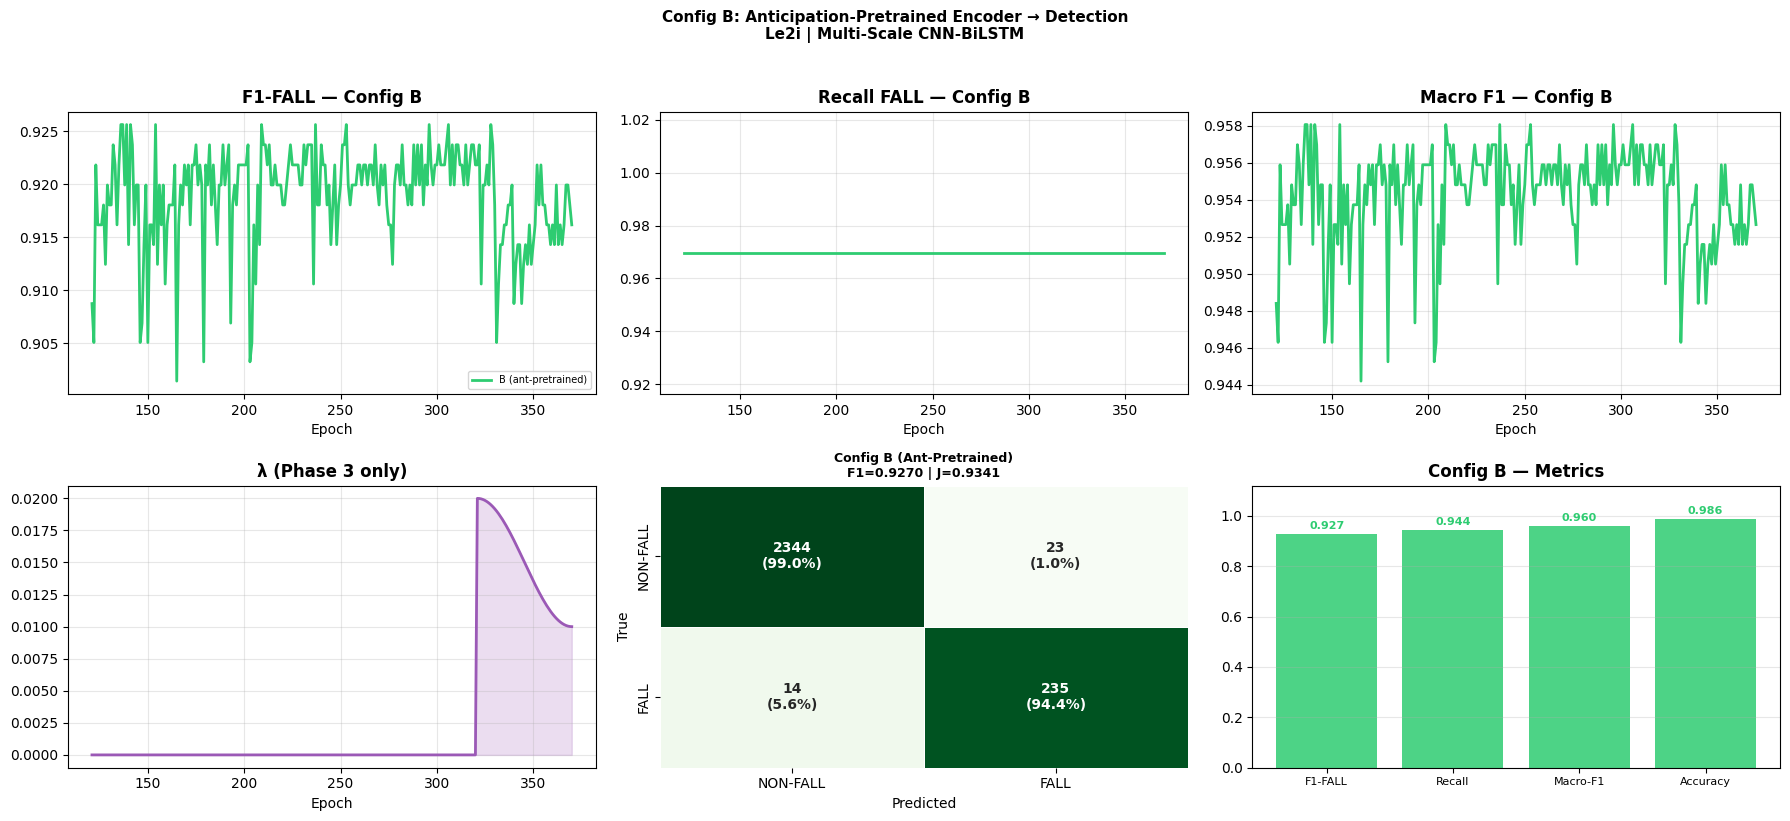

✅ Saved: /content/config_B_results.png


In [11]:
# =============================================================
# CELL 10 — Visualization: Training Curves + Confusion Matrix (Config B only)
# =============================================================

CB = '#2ECC71'
CLASS_NAMES = ['NON-FALL', 'FALL']

fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor('white')

# ── Training curves ──────────────────────────────────────────
ep = [h['epoch'] for h in history_B]

ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(ep, [h['f1_fall'] for h in history_B], color=CB, lw=2, label='B (ant-pretrained)')
ax1.set_title('F1-FALL — Config B', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(ep, [h['recall_fall'] for h in history_B], color=CB, lw=2)
ax2.set_title('Recall FALL — Config B', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(ep, [h['val_f1'] for h in history_B], color=CB, lw=2)
ax3.set_title('Macro F1 — Config B', fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(2, 3, 4)
lams = [h['lambda1'] for h in history_B]
ax4.plot(ep, lams, color='#9B59B6', lw=2)
ax4.fill_between(ep, lams, alpha=0.2, color='#9B59B6')
ax4.set_title('λ (Phase 3 only)', fontweight='bold')
ax4.set_xlabel('Epoch'); ax4.grid(alpha=0.3)

# ── Confusion matrix (numbers + percentages) ──────────────────
def plot_confusion_matrix(ax, TP, FP, TN, FN, title):
    total_nf = TN + FP; total_f = TP + FN
    cm_pct = np.array([[TN/max(total_nf,1)*100, FP/max(total_nf,1)*100],
                        [FN/max(total_f,1)*100,  TP/max(total_f,1)*100]])
    annots = np.array([[f'{TN}\n({TN/max(total_nf,1)*100:.1f}%)',
                         f'{FP}\n({FP/max(total_nf,1)*100:.1f}%)'],
                        [f'{FN}\n({FN/max(total_f,1)*100:.1f}%)',
                         f'{TP}\n({TP/max(total_f,1)*100:.1f}%)']])
    sns.heatmap(cm_pct, annot=annots, fmt='', cmap='Greens',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, linewidths=0.5,
                annot_kws={'size': 10, 'weight': 'bold'})
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

ax5 = fig.add_subplot(2, 3, 5)
plot_confusion_matrix(ax5, rB['tp'], rB['fp'], rB['tn'], rB['fn'],
    f'Config B (Ant-Pretrained)\nF1={rB["f1_fall"]:.4f} | J={rB["j"]:.4f}')

# ── Metric bar chart ───────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
metrics = ['F1-FALL', 'Recall', 'Macro-F1', 'Accuracy']
vB = [rB['f1_fall'], rB['recall'], rB['f1_macro'], rB['acc']]
x = np.arange(len(metrics))
ax6.bar(x, vB, color=CB, alpha=0.85)
ax6.set_xticks(x); ax6.set_xticklabels(metrics, fontsize=8)
ax6.set_ylim(0, 1.12)
ax6.set_title('Config B — Metrics', fontweight='bold'); ax6.grid(axis='y', alpha=0.3)
for xi, b in enumerate(vB):
    ax6.text(xi, b + 0.02, f'{b:.3f}', ha='center', fontsize=8, fontweight='bold', color=CB)

plt.suptitle(
    'Config B: Anticipation-Pretrained Encoder → Detection\n'
    'Le2i | Multi-Scale CNN-BiLSTM',
    fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/config_B_results.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Saved: /content/config_B_results.png')

In [13]:
# =============================================================
# CELL 11 — Lead Time Analysis + Final Report (Config B only)
# =============================================================

# ── Lead time: pre-impact alert capability of Config B ───────
# Config B alerts before impact using p_ant[:,1] > threshold

model_B.eval()
lead_times = []; alerted = 0; total_fall = 0

with torch.no_grad():
    for sample in labeled_data:
        if not sample['is_fall']: continue
        kp    = sample['keypoints']
        l_det = sample['labels_det']
        T     = len(kp)
        total_fall += 1
        if T < WINDOW_SIZE + 1: continue

        feats = extract_features(kp)
        wins, ends = [], []
        for s in range(0, T - WINDOW_SIZE):
            e = s + WINDOW_SIZE
            wins.append(feats[s:e]); ends.append(e - 1)

        xb = torch.tensor(np.array(wins), dtype=torch.float32).to(DEVICE)
        p_pre_fall = []
        for i in range(0, len(xb), 64):
            _, _, p_ant = model_B(xb[i:i+64])
            # PRE-FALL probability (class 1 of anticipation head)
            p_pre_fall.append(p_ant[:, 1].cpu().numpy())
        p_pre_fall = np.concatenate(p_pre_fall)

        first_alert = next((i for i, p in enumerate(p_pre_fall) if float(p) > 0.5), None)
        first_fall  = next((i for i, l in enumerate(l_det) if int(l) == 1), None)

        if first_alert is not None and first_fall is not None:
            lead = first_fall - ends[first_alert]
            if lead > 0:
                lead_times.append(lead); alerted += 1

print('── Lead Time Analysis: Config B ──────────────────────────')
print(f'   Total FALL sequences    : {total_fall}')
print(f'   Pre-impact alerts       : {alerted} ({alerted/max(total_fall,1)*100:.1f}%)')
if lead_times:
    arr = np.array(lead_times)
    print(f'   Mean lead time         : {arr.mean()/FPS_LE2I:.3f}s')
    print(f'   Median lead time       : {np.median(arr)/FPS_LE2I:.3f}s')
    print(f'   Max lead time          : {arr.max()/FPS_LE2I:.3f}s')

# ── Classification report ──────────────────────────────────────
print('\n── Classification Report: Config B (test set) ───────────')
model_B.eval()
preds_te, true_te = [], []
with torch.no_grad():
    for xb, _, yd in te_ld:
        xb = xb.to(DEVICE)
        _, logits_D, _ = model_B(xb)
        preds_te.extend(logits_D.argmax(1).cpu().numpy())
        true_te.extend(yd.numpy())
print(classification_report(true_te, preds_te, target_names=CLASS_NAMES, zero_division=0))

# ── Final summary ─────────────────────────────────────────────
lead_s = np.mean(lead_times)/FPS_LE2I if lead_times else 0

print('\n' + '=' * 65)
print('  FINAL SUMMARY — Config B')
print('=' * 65)
print(f'''
  Architecture:
    Shared   : Multi-Scale CNN-BiLSTM (kernel 3,7,15) + BiLSTM + Attention
    Config B : ant-pretrained encoder → z(512) → det_head → FALL/NON-FALL

  Test Results:
    F1-FALL  : {rB['f1_fall']:.4f}
    Recall   : {rB['recall']:.4f}
    Macro-F1 : {rB['f1_macro']:.4f}
    Accuracy : {rB['acc']:.4f}
    TP       : {rB['tp']:4d}
    FP       : {rB['fp']:4d}
    FN       : {rB['fn']:4d}
    TN       : {rB['tn']:4d}
    Youden J : {rB['j']:.4f}

  Pre-impact alert capability:
    Mean lead time   : {lead_s:.3f}s
    Alert coverage   : {alerted}/{total_fall} FALL sequences ({alerted/max(total_fall,1)*100:.1f}%)
''')

── Lead Time Analysis: Config B ──────────────────────────
   Total FALL sequences    : 93
   Pre-impact alerts       : 83 (89.2%)
   Mean lead time         : 1.040s
   Median lead time       : 0.800s
   Max lead time          : 9.320s

── Classification Report: Config B (test set) ───────────
              precision    recall  f1-score   support

    NON-FALL       0.99      0.99      0.99      2367
        FALL       0.91      0.94      0.93       249

    accuracy                           0.99      2616
   macro avg       0.95      0.97      0.96      2616
weighted avg       0.99      0.99      0.99      2616


  FINAL SUMMARY — Config B

  Architecture:
    Shared   : Multi-Scale CNN-BiLSTM (kernel 3,7,15) + BiLSTM + Attention
    Config B : ant-pretrained encoder → z(512) → det_head → FALL/NON-FALL

  Test Results:
    F1-FALL  : 0.9270
    Recall   : 0.9438
    Macro-F1 : 0.9596
    Accuracy : 0.9859
    TP       :  235
    FP       :   23
    FN       :   14
    TN       : 2344

In [14]:
import os
print('split_info.pkl existe :', os.path.exists('/content/split_info.pkl'))
print('le2i_data.pkl existe  :', os.path.exists('/content/le2i_data.pkl'))
if os.path.exists('/content/le2i_data.pkl'):
    print('Taille le2i_data.pkl :', os.path.getsize('/content/le2i_data.pkl')/1e6, 'MB')

split_info.pkl existe : True
le2i_data.pkl existe  : True
Taille le2i_data.pkl : 1.4378 MB


In [15]:
from google.colab import files
files.download('/content/split_info.pkl')
files.download('/content/le2i_data.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>